# Feature clustering & separability

Visualize handcrafted features and learned representations by behaviour label.

**Paper figures:**
- t-SNE on handcrafted features → `img/tsne_features.pdf` (cell under "t-SNE" section)
- t-SNE on learned representations (single model) → `img/tsne_learned_representations.pdf` (cell under "Single-model" section)

In [1]:
import os

os.chdir("../")

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib.lines import Line2D
from matplotlib import colormaps
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.classification.datamodule import BehaviourDataModule
from src.classification.model_selection import LOVO
from src.classification.models import MODEL_REGISTRY
from src.classification.trainer import BehaviourClassifier
from script.train import parse_input

## Load data

In [3]:
DATASET_DIR = "data/dataset"

# Load features and labels
features_df = pd.read_parquet(f"{DATASET_DIR}/features_windowed.parquet")
labels_df = pd.read_parquet(f"{DATASET_DIR}/labels.parquet")

# Merge on key columns
df = features_df.merge(labels_df, on=["video_id", "bird_id", "window"])

# Feature columns (drop keys and metadata)
skip_cols = {"video_id", "bird_id", "window", "n_frames",
             "bird_description", "time", "time_str",
             "behav", "behav_group", "behav_label"}
feat_cols = [c for c in df.columns if c not in skip_cols]

print(f"Samples: {len(df)}, Features: {len(feat_cols)}")
print(f"Labels: {df['behav_label'].value_counts().to_dict()}")
print(f"Feature cols: {feat_cols}")

Samples: 7505, Features: 171
Labels: {'none': 6436, 'worm': 691, 'locomotor': 311, 'social': 67}
Feature cols: ['mask_area_mean', 'mask_area_std', 'mask_area_median', 'mask_area_mad', 'mask_area_skew', 'mask_area_kurt', 'mask_area_cv', 'mask_area_q10', 'mask_area_q90', 'aspect_ratio_mean', 'aspect_ratio_std', 'aspect_ratio_median', 'aspect_ratio_mad', 'aspect_ratio_skew', 'aspect_ratio_kurt', 'aspect_ratio_cv', 'aspect_ratio_q10', 'aspect_ratio_q90', 'velocity_mean', 'velocity_std', 'velocity_median', 'velocity_mad', 'velocity_skew', 'velocity_kurt', 'velocity_cv', 'velocity_q10', 'velocity_q90', 'acceleration_mean', 'acceleration_std', 'acceleration_median', 'acceleration_mad', 'acceleration_skew', 'acceleration_kurt', 'acceleration_cv', 'acceleration_q10', 'acceleration_q90', 'area_change_rate_mean', 'area_change_rate_std', 'area_change_rate_median', 'area_change_rate_mad', 'area_change_rate_skew', 'area_change_rate_kurt', 'area_change_rate_cv', 'area_change_rate_q10', 'area_change_r

In [4]:
# Standardize features
X = df[feat_cols].fillna(df[feat_cols].median()).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.clip(X_scaled, -5, 5)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0)[:3].round(6)}")
print(f"Std  (should be ~1): {X_scaled.std(axis=0)[:3].round(6)}")

X_scaled shape: (7505, 171)
Mean (should be ~0): [-0.000735 -0.010304 -0.001001]
Std  (should be ~1): [0.995673 0.935937 0.993924]


In [ ]:
# Fine-grained behaviour labels + color palettes (needed for scatter plots below)
MIN_COUNT = 5  # behaviours below this are grouped as "Other"


def primary_behav(behav, group):
    """Extract primary fine-grained behaviour for a given group."""
    if behav == "none":
        return "None"
    parts = [p.strip() for p in behav.split(",")]
    if group == "worm":
        worm_parts = [p for p in parts if p.startswith("Worm")]
        return worm_parts[0] if worm_parts else parts[0]
    elif group == "social":
        social_parts = [p for p in parts if "Sparring" in p]
        return social_parts[0] if social_parts else parts[0]
    else:
        return parts[0]


df["behav_primary"] = df.apply(
    lambda r: primary_behav(r["behav"], r["behav_label"]), axis=1
)

# Collapse rare behaviours into "Other <group>"
for group in ["worm", "locomotor", "social"]:
    gmask = df["behav_label"] == group
    counts = df.loc[gmask, "behav_primary"].value_counts()
    rare = counts[counts < MIN_COUNT].index
    df.loc[gmask & df["behav_primary"].isin(rare), "behav_primary"] = f"Other {group}"


def sample_palette(cmap_name, n, lo=0.3, hi=0.85):
    """Sample n distinct colors from a sequential colormap."""
    cmap = colormaps[cmap_name]
    return [cmap(x) for x in np.linspace(lo, hi, max(n, 1))]


group_cmaps = {"worm": "OrRd", "locomotor": "PuBu", "social": "YlGn"}
label_colors = {
    "none": "#cccccc",
    "worm": "#e74c3c",
    "locomotor": "#3498db",
    "social": "#2ecc71",
}

color_map = {"None": "#d5d5d5"}
for group, cmap_name in group_cmaps.items():
    behavs = (
        df.loc[df["behav_label"] == group, "behav_primary"]
        .value_counts()
        .index.tolist()
    )
    colors = sample_palette(cmap_name, len(behavs))
    for behav, color in zip(behavs, colors):
        color_map[behav] = color

# Build grouped legend handles (reused across PCA and t-SNE)
none_mask = df["behav_label"] == "none"
group_labels = {
    "none": "None",
    "worm": "Worm",
    "locomotor": "Locomotor",
    "social": "Social",
}
legend_handles = []
for group in ["none", "worm", "locomotor", "social"]:
    legend_handles.append(
        Line2D(
            [],
            [],
            marker="none",
            linestyle="none",
            label=f"$\\bf{{{group_labels[group]}}}$",
        )
    )
    if group == "none":
        n = none_mask.sum()
        legend_handles.append(
            Line2D(
                [],
                [],
                marker="o",
                color="w",
                markerfacecolor=color_map["None"],
                markersize=7,
                linestyle="none",
                label=f"  None ({n})",
            )
        )
    else:
        behavs = df.loc[df["behav_label"] == group, "behav_primary"].value_counts()
        for behav, count in behavs.items():
            legend_handles.append(
                Line2D(
                    [],
                    [],
                    marker="o",
                    color="w",
                    markerfacecolor=color_map[behav],
                    markersize=7,
                    linestyle="none",
                    label=f"  {behav} ({count})",
                )
            )

print(f"Fine-grained behaviours: {df['behav_primary'].nunique()}")
print(df["behav_primary"].value_counts().to_string())

Fine-grained behaviours: 12
behav_primary
None                             6436
Worm pecking                      471
Frolicking                        284
Worm running                       95
Worm chasing                       65
Worm running mealworm              60
Sparring stand-off no contact      56
Running                            12
Wing flapping                      10
Other social                        6
Sparring jumping contact            5
Spinning while wing flapping        5


---

## Exploratory analysis

## PCA

In [14]:
# Full PCA for scree plot + 3-component PCA for scatter plots
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_full_df = pd.DataFrame({
    "PC": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "Explained Variance Ratio": pca_full.explained_variance_ratio_,
})

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}, PC3={pca.explained_variance_ratio_[2]:.3f}")
print(f"Total (3 PCs): {pca.explained_variance_ratio_.sum():.3f}")
print(f"Components for 90% variance: {np.searchsorted(np.cumsum(pca_full.explained_variance_ratio_), 0.9) + 1}")
print(f"Components for 95% variance: {np.searchsorted(np.cumsum(pca_full.explained_variance_ratio_), 0.95) + 1}")

Explained variance: PC1=0.210, PC2=0.087, PC3=0.074
Total (3 PCs): 0.371
Components for 90% variance: 45
Components for 95% variance: 63


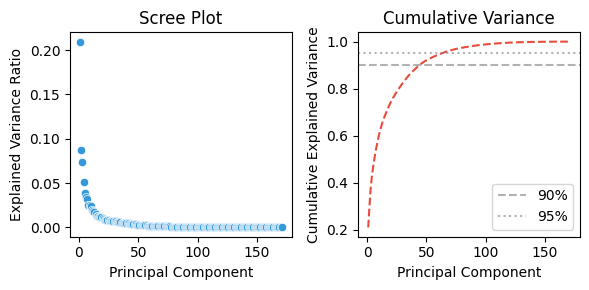

In [15]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

n_comp = len(pca_full.explained_variance_ratio_)
x = np.arange(1, n_comp + 1)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Left: individual explained variance
sns.scatterplot(x=x, y=pca_full.explained_variance_ratio_, color="#3498db", edgecolor="white", ax=axes[0])
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

# Right: cumulative explained variance
axes[1].plot(x, cumvar, "--", color="#e74c3c", markersize=1)
axes[1].axhline(0.9, ls="--", color="grey", alpha=0.6, label="90%")
axes[1].axhline(0.95, ls=":", color="grey", alpha=0.6, label="95%")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

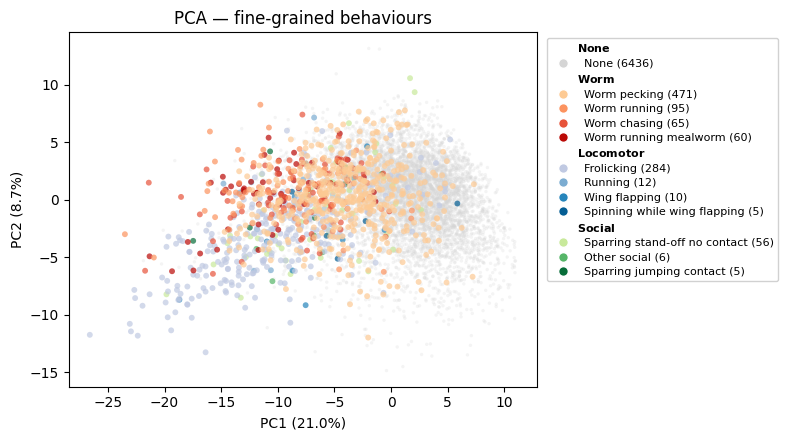

In [17]:
# PC1 vs PC2 colored by fine-grained behaviour (behav_primary)
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.scatter(
    X_pca[none_mask, 0], X_pca[none_mask, 1],
    c=color_map["None"], s=6, alpha=0.25, edgecolors="none",
)

for group in ["social", "locomotor", "worm"]:
    gmask = df["behav_label"] == group
    behavs = df.loc[gmask, "behav_primary"].value_counts().index.tolist()
    for behav in reversed(behavs):
        bmask = df["behav_primary"] == behav
        ax.scatter(
            X_pca[bmask, 0], X_pca[bmask, 1],
            c=[color_map[behav]], s=18, alpha=0.7, edgecolors="none",
        )

ax.legend(
    handles=legend_handles, fontsize=8, loc="upper left",
    bbox_to_anchor=(1.01, 1), frameon=True, framealpha=0.9,
    handletextpad=0.3, labelspacing=0.4,
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA — fine-grained behaviours")
plt.tight_layout()
plt.show()

## Rotated PCA loadings (varimax + Kaiser normalization)

Varimax rotation redistributes explained variance across components to produce
simpler, more interpretable loadings (each feature loads heavily on fewer PCs).

In [20]:
# --- Pure-Python varimax rotation (no rpy2/R dependency) ---

def varimax(Phi, gamma=1.0, max_iter=100, tol=1e-6):
    """Varimax rotation of a loading matrix.

    Args:
        Phi: (p, k) loading matrix (features x components)
        gamma: 1.0 = varimax, 0.0 = quartimax
    Returns:
        rotated_loadings: (p, k)
        rotation_matrix: (k, k)
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(max_iter):
        Lambda = Phi @ R
        u, s, vt = np.linalg.svd(
            Phi.T @ (Lambda ** 3 - (gamma / p) * Lambda @ np.diag((Lambda ** 2).sum(axis=0)))
        )
        R = u @ vt
        d_new = s.sum()
        if d_new - d < tol:
            break
        d = d_new
    return Phi @ R, R


def rotated_pca(X, n_components, normalize=True, random_state=42):
    """PCA with varimax rotation and optional Kaiser normalization.

    Returns fitted PCA object (with rotated components/variance) and
    the rotated loading matrix (p, k).
    """
    pca_r = PCA(n_components=n_components, random_state=random_state)
    pca_r.fit(X)

    # Loadings = eigenvectors * sqrt(eigenvalues)
    loadings = pca_r.components_.T * np.sqrt(pca_r.explained_variance_)

    if normalize:
        # Kaiser normalization: normalize rows before rotation, denormalize after
        sc = np.sqrt((loadings ** 2).sum(axis=1, keepdims=True))
        sc = np.clip(sc, 1e-10, None)
        loadings_rot, _ = varimax(loadings / sc)
        loadings_rot = loadings_rot * sc
    else:
        loadings_rot, _ = varimax(loadings)

    # Update PCA object with rotated quantities
    pca_r.explained_variance_ = (loadings_rot ** 2).sum(axis=0)
    pca_r.components_ = (loadings_rot / np.sqrt(pca_r.explained_variance_)).T

    # Re-sort by explained variance
    ev_order = np.argsort(pca_r.explained_variance_)[::-1]
    pca_r.components_ = pca_r.components_[ev_order, :]
    pca_r.explained_variance_ = pca_r.explained_variance_[ev_order]
    pca_r.explained_variance_ratio_ = pca_r.explained_variance_ / pca_r.explained_variance_.sum()
    loadings_rot = loadings_rot[:, ev_order]

    return pca_r, loadings_rot


N_COMPONENTS = 10
pca_rot, loadings = rotated_pca(X_scaled, n_components=N_COMPONENTS)

print("Rotated PCA explained variance ratios:")
for i in range(N_COMPONENTS):
    print(f"  PC{i+1}: {pca_rot.explained_variance_ratio_[i]:.3f}")
print(f"  Total: {pca_rot.explained_variance_ratio_.sum():.3f}")

Rotated PCA explained variance ratios:
  PC1: 0.263
  PC2: 0.147
  PC3: 0.121
  PC4: 0.091
  PC5: 0.084
  PC6: 0.081
  PC7: 0.069
  PC8: 0.055
  PC9: 0.050
  PC10: 0.039
  Total: 1.000


In [21]:
# Top loadings per rotated PC
N_TOP = 8

for i in range(N_COMPONENTS):
    top_idx = np.abs(loadings[:, i]).argsort()[::-1][:N_TOP]
    top_names = [feat_cols[j] for j in top_idx]
    top_vals = loadings[top_idx, i]

    print(f"PC{i+1} ({pca_rot.explained_variance_ratio_[i]:.1%})")
    for name, val in zip(top_names, top_vals):
        bar = "+" if val > 0 else "-"
        print(f"  {bar} {abs(val):.3f}  {name}")
    print()

PC1 (26.3%)
  - 0.862  acceleration_mad
  + 0.845  elongation_change_q10
  - 0.845  elongation_change_mad
  - 0.844  elongation_change_q90
  + 0.826  acceleration_q10
  - 0.813  velocity_mad
  - 0.806  area_change_rate_mad
  - 0.755  dist_change_rate_mad

PC2 (14.7%)
  + 0.898  solidity_q10
  - 0.885  circularity_cv
  + 0.872  circularity_q10
  + 0.854  solidity_mean
  - 0.848  solidity_std
  - 0.834  solidity_cv
  - 0.774  circularity_std
  + 0.722  circularity_mean

PC3 (12.1%)
  + 0.926  eccentricity_q10
  + 0.919  elongation_q10
  + 0.907  eccentricity_mean
  + 0.848  elongation_mean
  + 0.844  elongation_median
  + 0.836  eccentricity_median
  - 0.767  eccentricity_cv
  - 0.730  eccentricity_std

PC4 (9.1%)
  + 0.900  min_dist_to_other_mean
  + 0.898  mean_dist_to_other_mean
  + 0.892  mean_dist_to_other_median
  + 0.887  min_dist_to_other_median
  + 0.847  mean_dist_to_other_q10
  + 0.831  mean_dist_to_other_q90
  + 0.829  min_dist_to_other_q90
  + 0.790  min_dist_to_other_q10

P

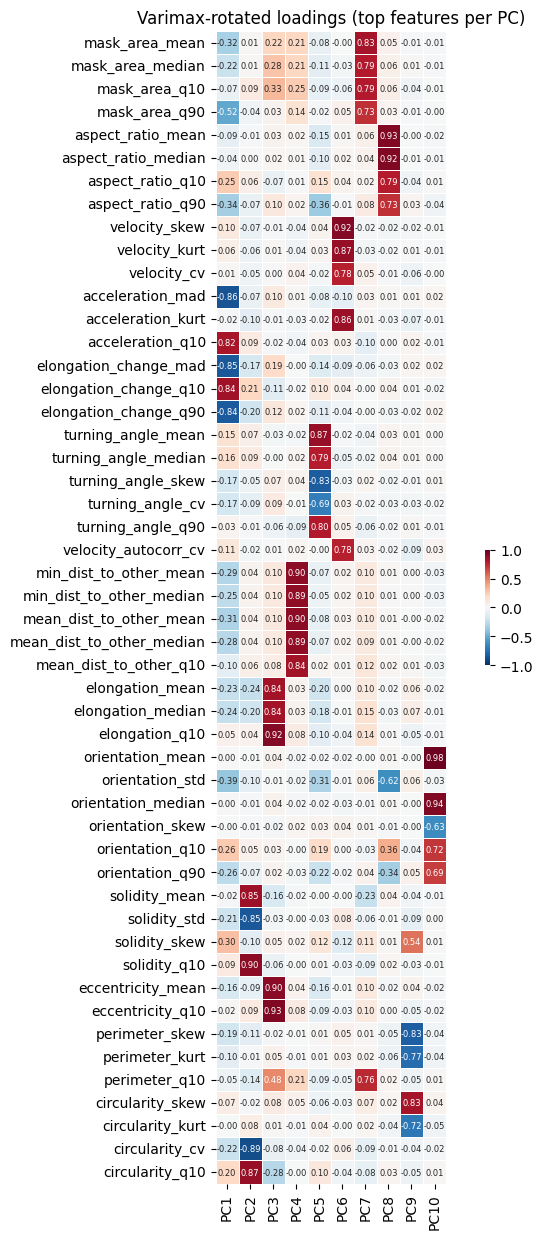

In [51]:
# Loadings heatmap — top features per PC
N_SHOW = 5  # top features per PC to include in heatmap

# Collect unique top features across all PCs
top_feat_idx = set()
for i in range(N_COMPONENTS):
    top_feat_idx.update(np.abs(loadings[:, i]).argsort()[::-1][:N_SHOW])
top_feat_idx = sorted(top_feat_idx)

loadings_sub = loadings[top_feat_idx, :]
feat_names_sub = [feat_cols[j] for j in top_feat_idx]

fig, ax = plt.subplots(figsize=(N_COMPONENTS * 0.8, len(feat_names_sub) * 0.25))
sns.heatmap(
    loadings_sub,
    xticklabels=[f"PC{i+1}" for i in range(N_COMPONENTS)],
    yticklabels=feat_names_sub,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.5, ax=ax, fmt=".2f",
    annot=True, annot_kws={"fontsize": 6}, cbar_kws = {"shrink": 0.1}
)
ax.set_title("Varimax-rotated loadings (top features per PC)")
plt.tight_layout()
plt.show()

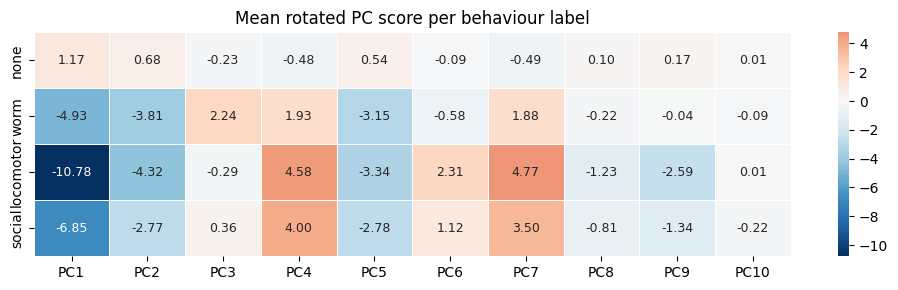

In [52]:
# Mean PC scores per behaviour label — which PCs discriminate which groups?
X_rot = X_scaled @ pca_rot.components_.T  # (n_samples, n_components)

pc_cols = [f"PC{i+1}" for i in range(N_COMPONENTS)]
scores_df = pd.DataFrame(X_rot, columns=pc_cols)
scores_df["behav_label"] = df["behav_label"].values
scores_df["behav_primary"] = df["behav_primary"].values

# --- Per behaviour label ---
mean_by_label = scores_df.groupby("behav_label")[pc_cols].mean()

fig, ax = plt.subplots(figsize=(N_COMPONENTS * 1.0, 3))
sns.heatmap(
    mean_by_label.loc[["none", "worm", "locomotor", "social"]],
    cmap="RdBu_r", center=0, annot=True, fmt=".2f",
    linewidths=0.5, ax=ax, annot_kws={"fontsize": 9},
)
ax.set_title("Mean rotated PC score per behaviour label")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

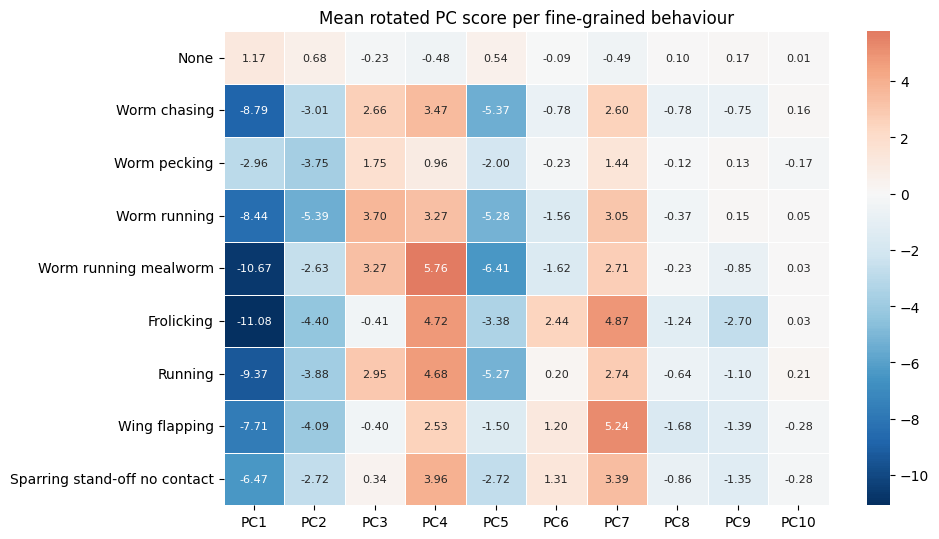

In [45]:
# --- Per fine-grained behaviour ---
# Filter to behaviours with enough samples
behav_counts = scores_df["behav_primary"].value_counts()
keep_behavs = behav_counts[behav_counts >= 10].index
scores_fg = scores_df[scores_df["behav_primary"].isin(keep_behavs)]

mean_by_fg = scores_fg.groupby("behav_primary")[pc_cols].mean()

# Sort rows by behav_label group for readability
behav_order = []
for group in ["none", "worm", "locomotor", "social"]:
    group_behavs = df.loc[df["behav_label"] == group, "behav_primary"].unique()
    behav_order.extend(sorted(b for b in group_behavs if b in mean_by_fg.index))
mean_by_fg = mean_by_fg.loc[behav_order]

fig, ax = plt.subplots(figsize=(N_COMPONENTS * 1.0, len(behav_order) * 0.5 + 1))
sns.heatmap(
    mean_by_fg,
    cmap="RdBu_r", center=0, annot=True, fmt=".2f",
    linewidths=0.5, ax=ax, annot_kws={"fontsize": 8},
)
ax.set_title("Mean rotated PC score per fine-grained behaviour")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## t-SNE

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
print(f"t-SNE done: {X_tsne.shape}")

t-SNE done: (7505, 2)


In [10]:
np.savez(
    "data/tsne/features.npz",
    tsne_features=X_tsne,
)

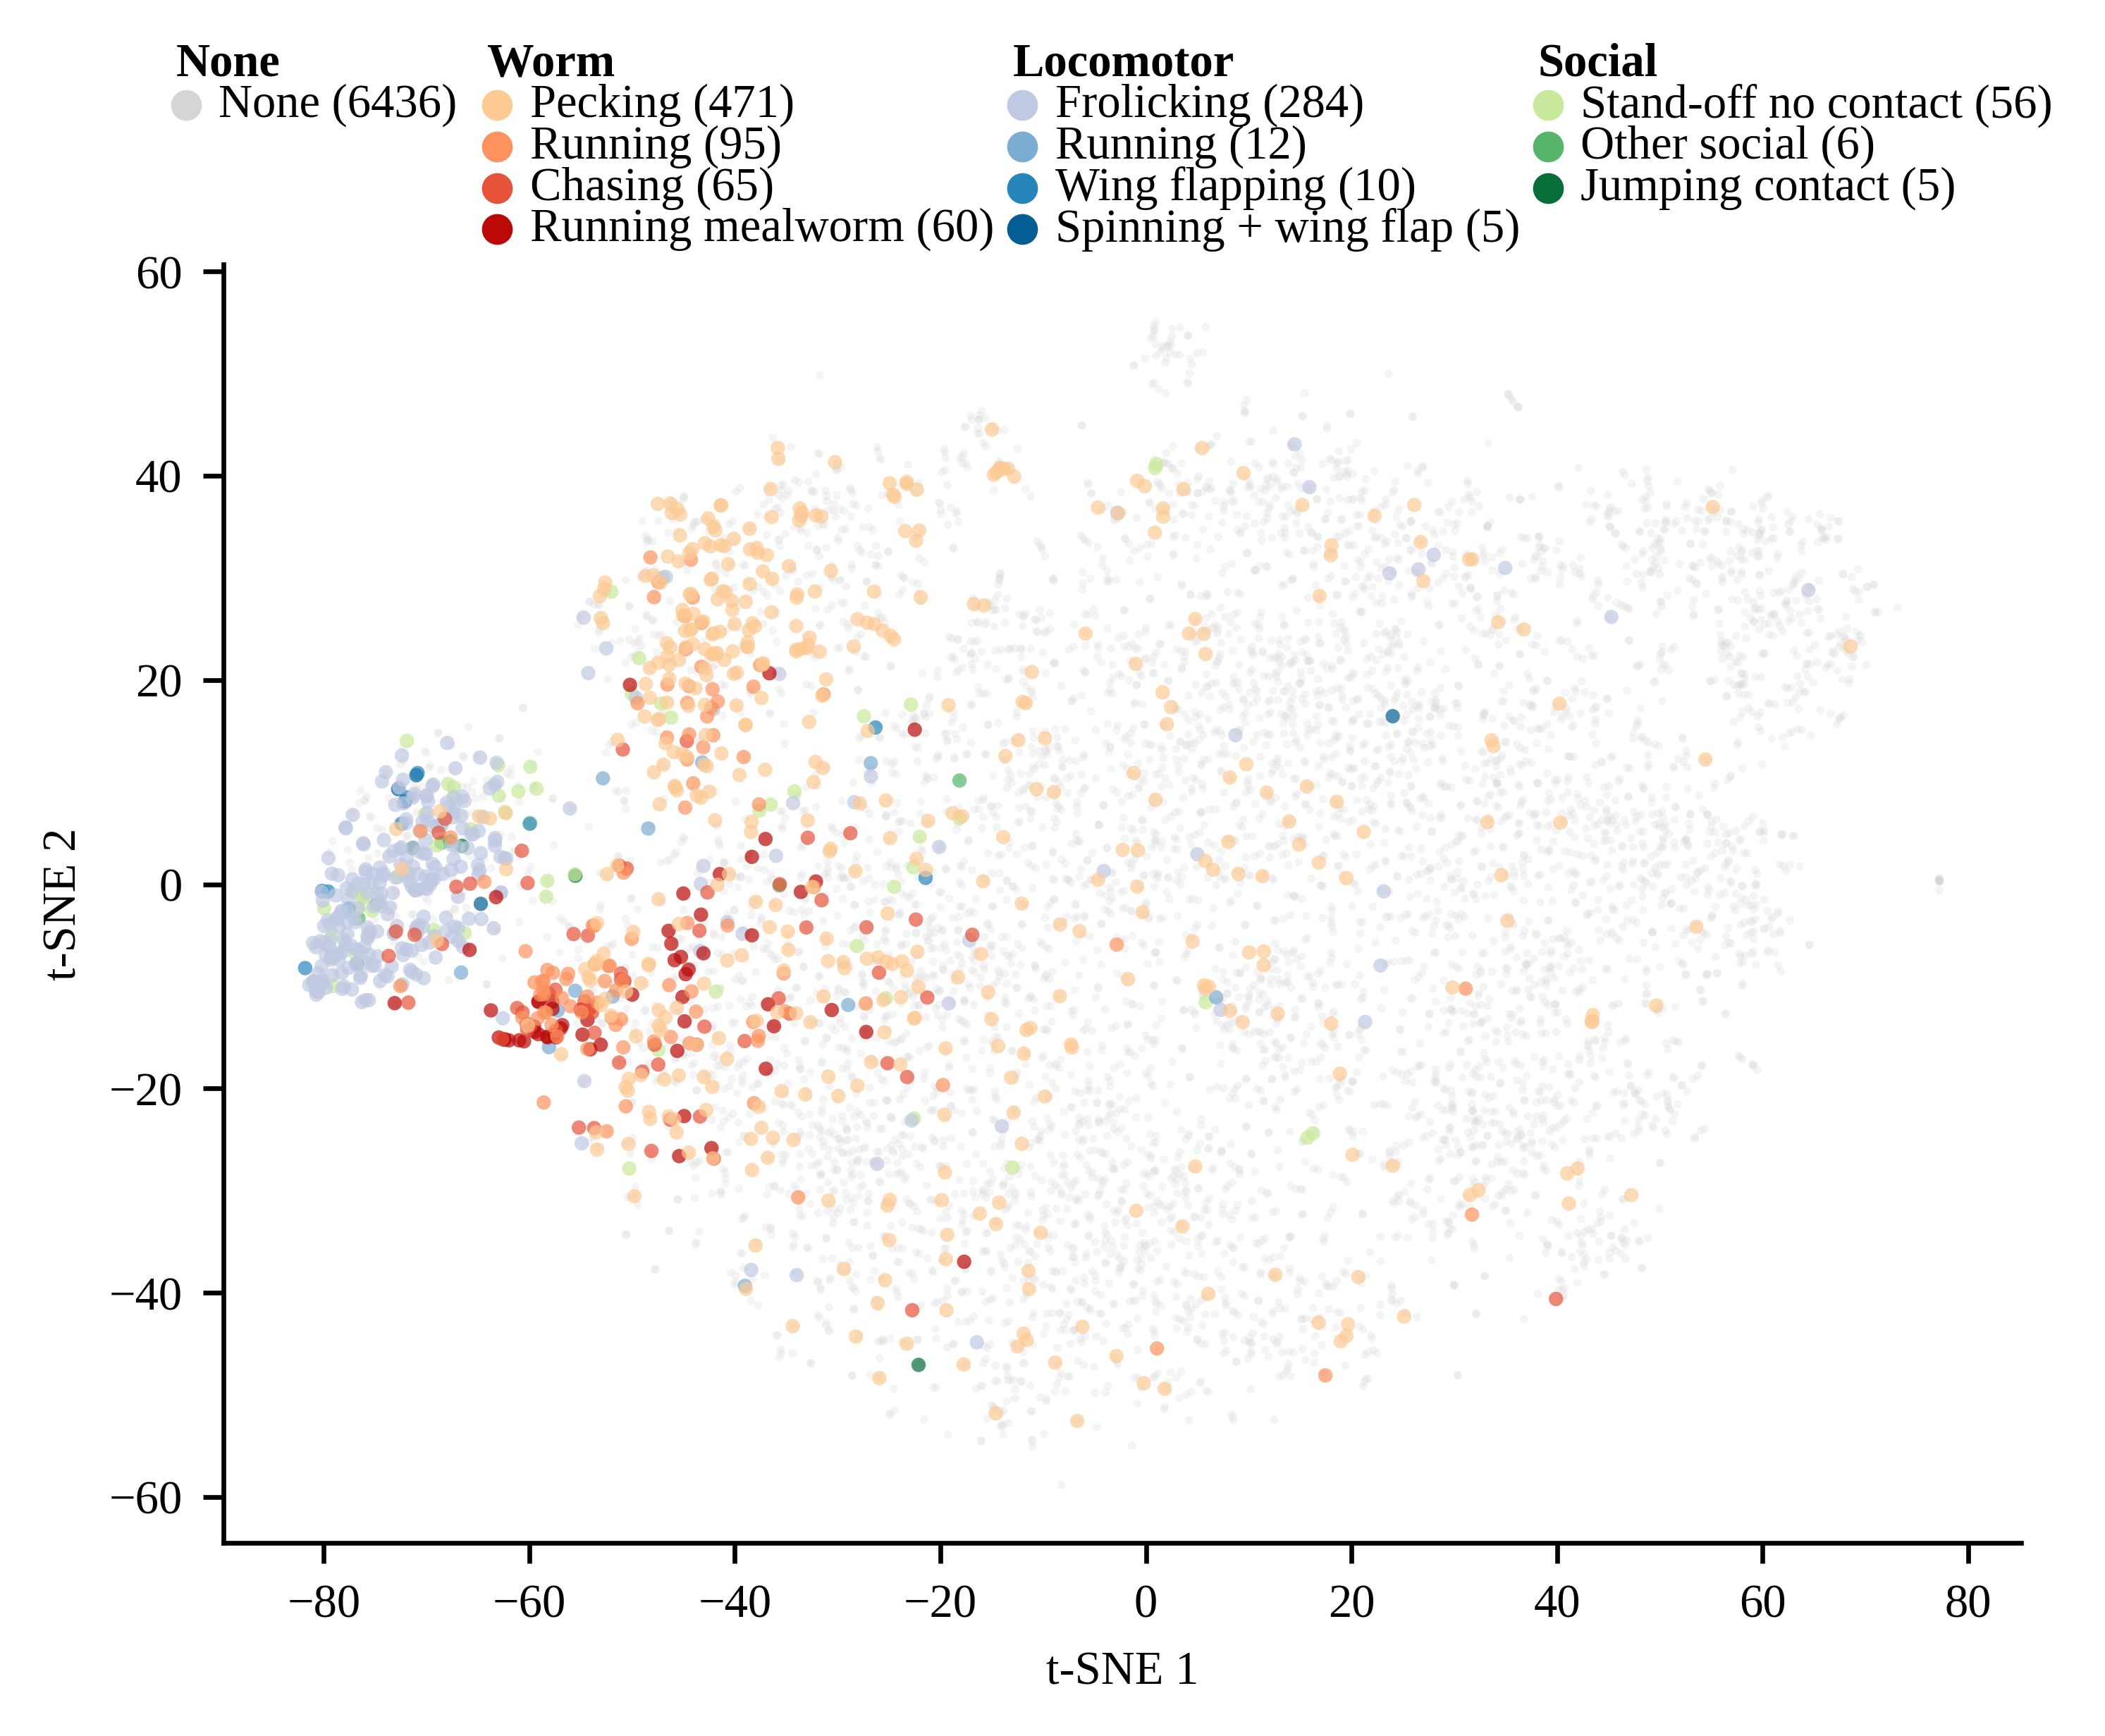

In [18]:
with plt.style.context(".matplotlib/ieee.mplstyle"):
    # t-SNE colored by fine-grained behaviour — same palettes as PCA
    fig = plt.figure(figsize=(5, 4.2))
    leg_ax = fig.add_axes([0.05, 0.80, 0.92, 0.14])  # tight legend strip at top
    ax = fig.add_axes([0.10, 0.10, 0.85, 0.72])  # plot fills rest

    # Draw "none" as background
    ax.scatter(
        X_tsne[none_mask, 0], X_tsne[none_mask, 1],
        c=color_map["None"], s=2, alpha=0.25, edgecolors="none",
    )

    # Draw active behaviours on top, group by group
    for group in ["social", "locomotor", "worm"]:
        gmask = df["behav_label"] == group
        behavs = (
            df.loc[gmask, "behav_primary"]
            .value_counts()
            .index.tolist()
        )
        for behav in reversed(behavs):
            bmask = df["behav_primary"] == behav
            ax.scatter(
                X_tsne[bmask, 0], X_tsne[bmask, 1],
                c=[color_map[behav]], s=6, alpha=0.7, edgecolors="none",
            )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    # --- Custom 4-column legend at top ---
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")

    group_order = ["none", "worm", "locomotor", "social"]
    group_titles = {"none": "None", "worm": "Worm", "locomotor": "Locomotor", "social": "Social"}

    # Short labels: strip "Worm " prefix, shorten long names
    short_labels = {
        "Worm pecking": "Pecking",
        "Worm running": "Running",
        "Worm chasing": "Chasing",
        "Worm running mealworm": "Running mealworm",
        "Sparring stand-off no contact": "Stand-off no contact",
        "Sparring jumping contact": "Jumping contact",
        "Spinning while wing flapping": "Spinning + wing flap",
        "Wing flapping": "Wing flapping",
    }

    col_entries = {}
    for group in group_order:
        entries = []
        if group == "none":
            n = none_mask.sum()
            entries.append((color_map["None"], f"None ({n})"))
        else:
            behavs = df.loc[df["behav_label"] == group, "behav_primary"].value_counts()
            for behav, count in behavs.items():
                label = short_labels.get(behav, behav)
                entries.append((color_map[behav], f"{label} ({count})"))
        col_entries[group] = entries

    # Compute vertical layout: center all rows within the legend axes
    max_rows = max(len(e) for e in col_entries.values())
    total_rows = 1 + max_rows  # header + entries
    row_height = 1.0 / (total_rows + 1)
    top_y = 0.95

    col_x = [0.03, 0.19, 0.46, 0.73]

    for col_idx, group in enumerate(group_order):
        x = col_x[col_idx]
        y = top_y
        leg_ax.text(x, y, group_titles[group], fontweight="bold",
                    va="center", transform=leg_ax.transAxes)
        for row_idx, (color, label) in enumerate(col_entries[group]):
            y = top_y - (row_idx + 1) * row_height
            leg_ax.scatter(x + 0.005, y, c=[color], s=18, transform=leg_ax.transAxes,
                        clip_on=False, zorder=5)
            leg_ax.text(x + 0.022, y, label, va="center",
                        linespacing=0.8, transform=leg_ax.transAxes)
    sns.despine()
    plt.savefig("img/tsne_features.pdf")
    plt.show()

## t-SNE on learned representations (TemporalCNNv2)

Extract penultimate-layer representations from LOVO checkpoints (`20260316_111332_temporal_cnn2`).
Each fold's test set is processed by its own checkpoint (no data leakage).
Representation = output after gated attention pool, before classification head (128-d + flat features).

**Note:** Multi-model extraction (one model per fold) causes video clustering artifact — see single-model section below for the paper figure.

In [ ]:
def extract_penultimate(backbone, data, flat=None):
    """Run TemporalCNNv2 forward up to (but not including) the classification head.

    Returns the representation after gated attention pool + flat concat.
    """
    with torch.no_grad():
        x = backbone.proj(data)  # (B, K, 256)
        x = x.transpose(1, 2)  # (B, 256, K)
        x = F.gelu(backbone.conv(x))  # (B, d_hidden, K)
        x = x.transpose(1, 2)  # (B, K, d_hidden)
        x = backbone.pool(x)  # (B, d_hidden)
        if flat is not None:
            x = torch.cat([x, flat], dim=-1)
    return x

In [ ]:
# Best run
RUN_DIR = Path("data/eval/20260316_111332_temporal_cnn2")

# Load run config
with open(RUN_DIR / "cfg.json") as f:
    cfg = json.load(f)
print(json.dumps(cfg, indent=2))

# Parse input spec to get data loading flags
use_features, use_embeddings, embeddings_files = parse_input(cfg["input"])
backbone_cls, temporal = MODEL_REGISTRY[cfg["model"]]

# Build datamodule with exact same config
dm = BehaviourDataModule(
    dataset_dir=cfg["dataset_dir"],
    splitter=LOVO(),
    batch_size=cfg["batch_size"],
    exclude=cfg["exclude"],
    use_features=use_features,
    use_embeddings=use_embeddings,
    temporal=temporal,
    embeddings_files=embeddings_files,
    n_segments=cfg["n_segments"],
)
dm.prepare_data()
print(f"\nDataset: {len(dm._dataset)} samples, {dm._dataset.n_classes} classes")
print(f"Videos: {dm.video_ids}")

## Single-model t-SNE (PAPER FIGURE)

Use fold 4 (test=C2G2, best F1=0.82) and extract representations for ALL videos through this single model.
This avoids the cross-model representation space artifact. Confirms model learns behaviour, not cage identity.

In [ ]:
# Load the best fold's checkpoint (fold 4 = C2G2)
fold_dir = RUN_DIR / "fold_4_C2G2"
ckpt_path = sorted((fold_dir / "checkpoints").glob("*.ckpt"))[0]

backbone_kwargs = {}
if dm.flat_dim > 0:
    backbone_kwargs["d_flat"] = dm.flat_dim
if cfg["dropout"] is not None:
    backbone_kwargs["dropout"] = cfg["dropout"]
if cfg["d_hidden"] is not None:
    backbone_kwargs["d_hidden"] = cfg["d_hidden"]

single_model = BehaviourClassifier(
    backbone=backbone_cls(dm.data_dim, dm.n_classes, **backbone_kwargs),
    n_classes=dm.n_classes,
    lr=cfg["lr"],
)
ckpt = torch.load(ckpt_path, weights_only=True)
single_model.load_state_dict(ckpt["state_dict"], strict=False)
single_model.eval()

# Extract representations for ALL videos through this single model
single_reprs = []
single_labels = []
single_videos = []

all_videos = dm.video_ids

for test_id, val_id in dm.splitter.split(all_videos):
    dm.set_fold(test_id=test_id, val_id=val_id)
    dm.setup()

    for batch in dm.test_dataloader():
        repr_vec = extract_penultimate(single_model.backbone, batch["data"], batch.get("flat"))
        single_reprs.append(repr_vec)
        single_labels.append(batch["label"])
        single_videos.extend([test_id] * len(batch["label"]))

X_single = torch.cat(single_reprs).numpy()
y_single = torch.cat(single_labels).numpy()

print(f"Single model representations: {X_single.shape}")
print(f"Videos: {pd.Series(single_videos).value_counts().to_dict()}")

In [33]:
# Build metadata for single-model representations
single_df = pd.DataFrame({"video_id": single_videos, "label_idx": y_single})
single_df["behav_label"] = [dm._dataset.label_encoder.decode(int(i)) for i in y_single]

# Re-derive fine-grained behaviours
single_keys = []
dataset = dm._dataset
for test_video in all_videos:
    test_indices = [i for i, g in enumerate(dataset.groups) if g == test_video]
    single_keys.extend(test_indices)

labels_full = pd.read_parquet(f"{cfg['dataset_dir']}/labels.parquet")
if cfg["exclude"]:
    labels_full = labels_full[labels_full["behav_label"] != cfg["exclude"]].reset_index(drop=True)

single_df["behav"] = labels_full.iloc[single_keys]["behav"].values
single_df["behav_primary"] = single_df.apply(
    lambda r: primary_behav(r["behav"], r["behav_label"]), axis=1
)
for group in ["worm", "locomotor"]:
    gmask = single_df["behav_label"] == group
    counts = single_df.loc[gmask, "behav_primary"].value_counts()
    rare = counts[counts < MIN_COUNT].index
    single_df.loc[gmask & single_df["behav_primary"].isin(rare), "behav_primary"] = f"Other {group}"

none_mask_single = single_df["behav_label"] == "none"
print(f"Samples: {len(single_df)}")
print(single_df["behav_primary"].value_counts().to_string())

Samples: 7438
behav_primary
None                            6436
Worm pecking                     471
Frolicking                       284
Worm running                      95
Worm chasing                      65
Worm running mealworm             60
Running                           12
Wing flapping                     10
Spinning while wing flapping       5


In [32]:
# t-SNE on single model — fine-grained behaviours (IEEE style)
tsne_single = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_single = tsne_single.fit_transform(X_single)
print(f"t-SNE done: {X_tsne_single.shape}")

np.savez("data/tsne/best.npz", tsne_features=X_tsne_single,)

t-SNE done: (7438, 2)


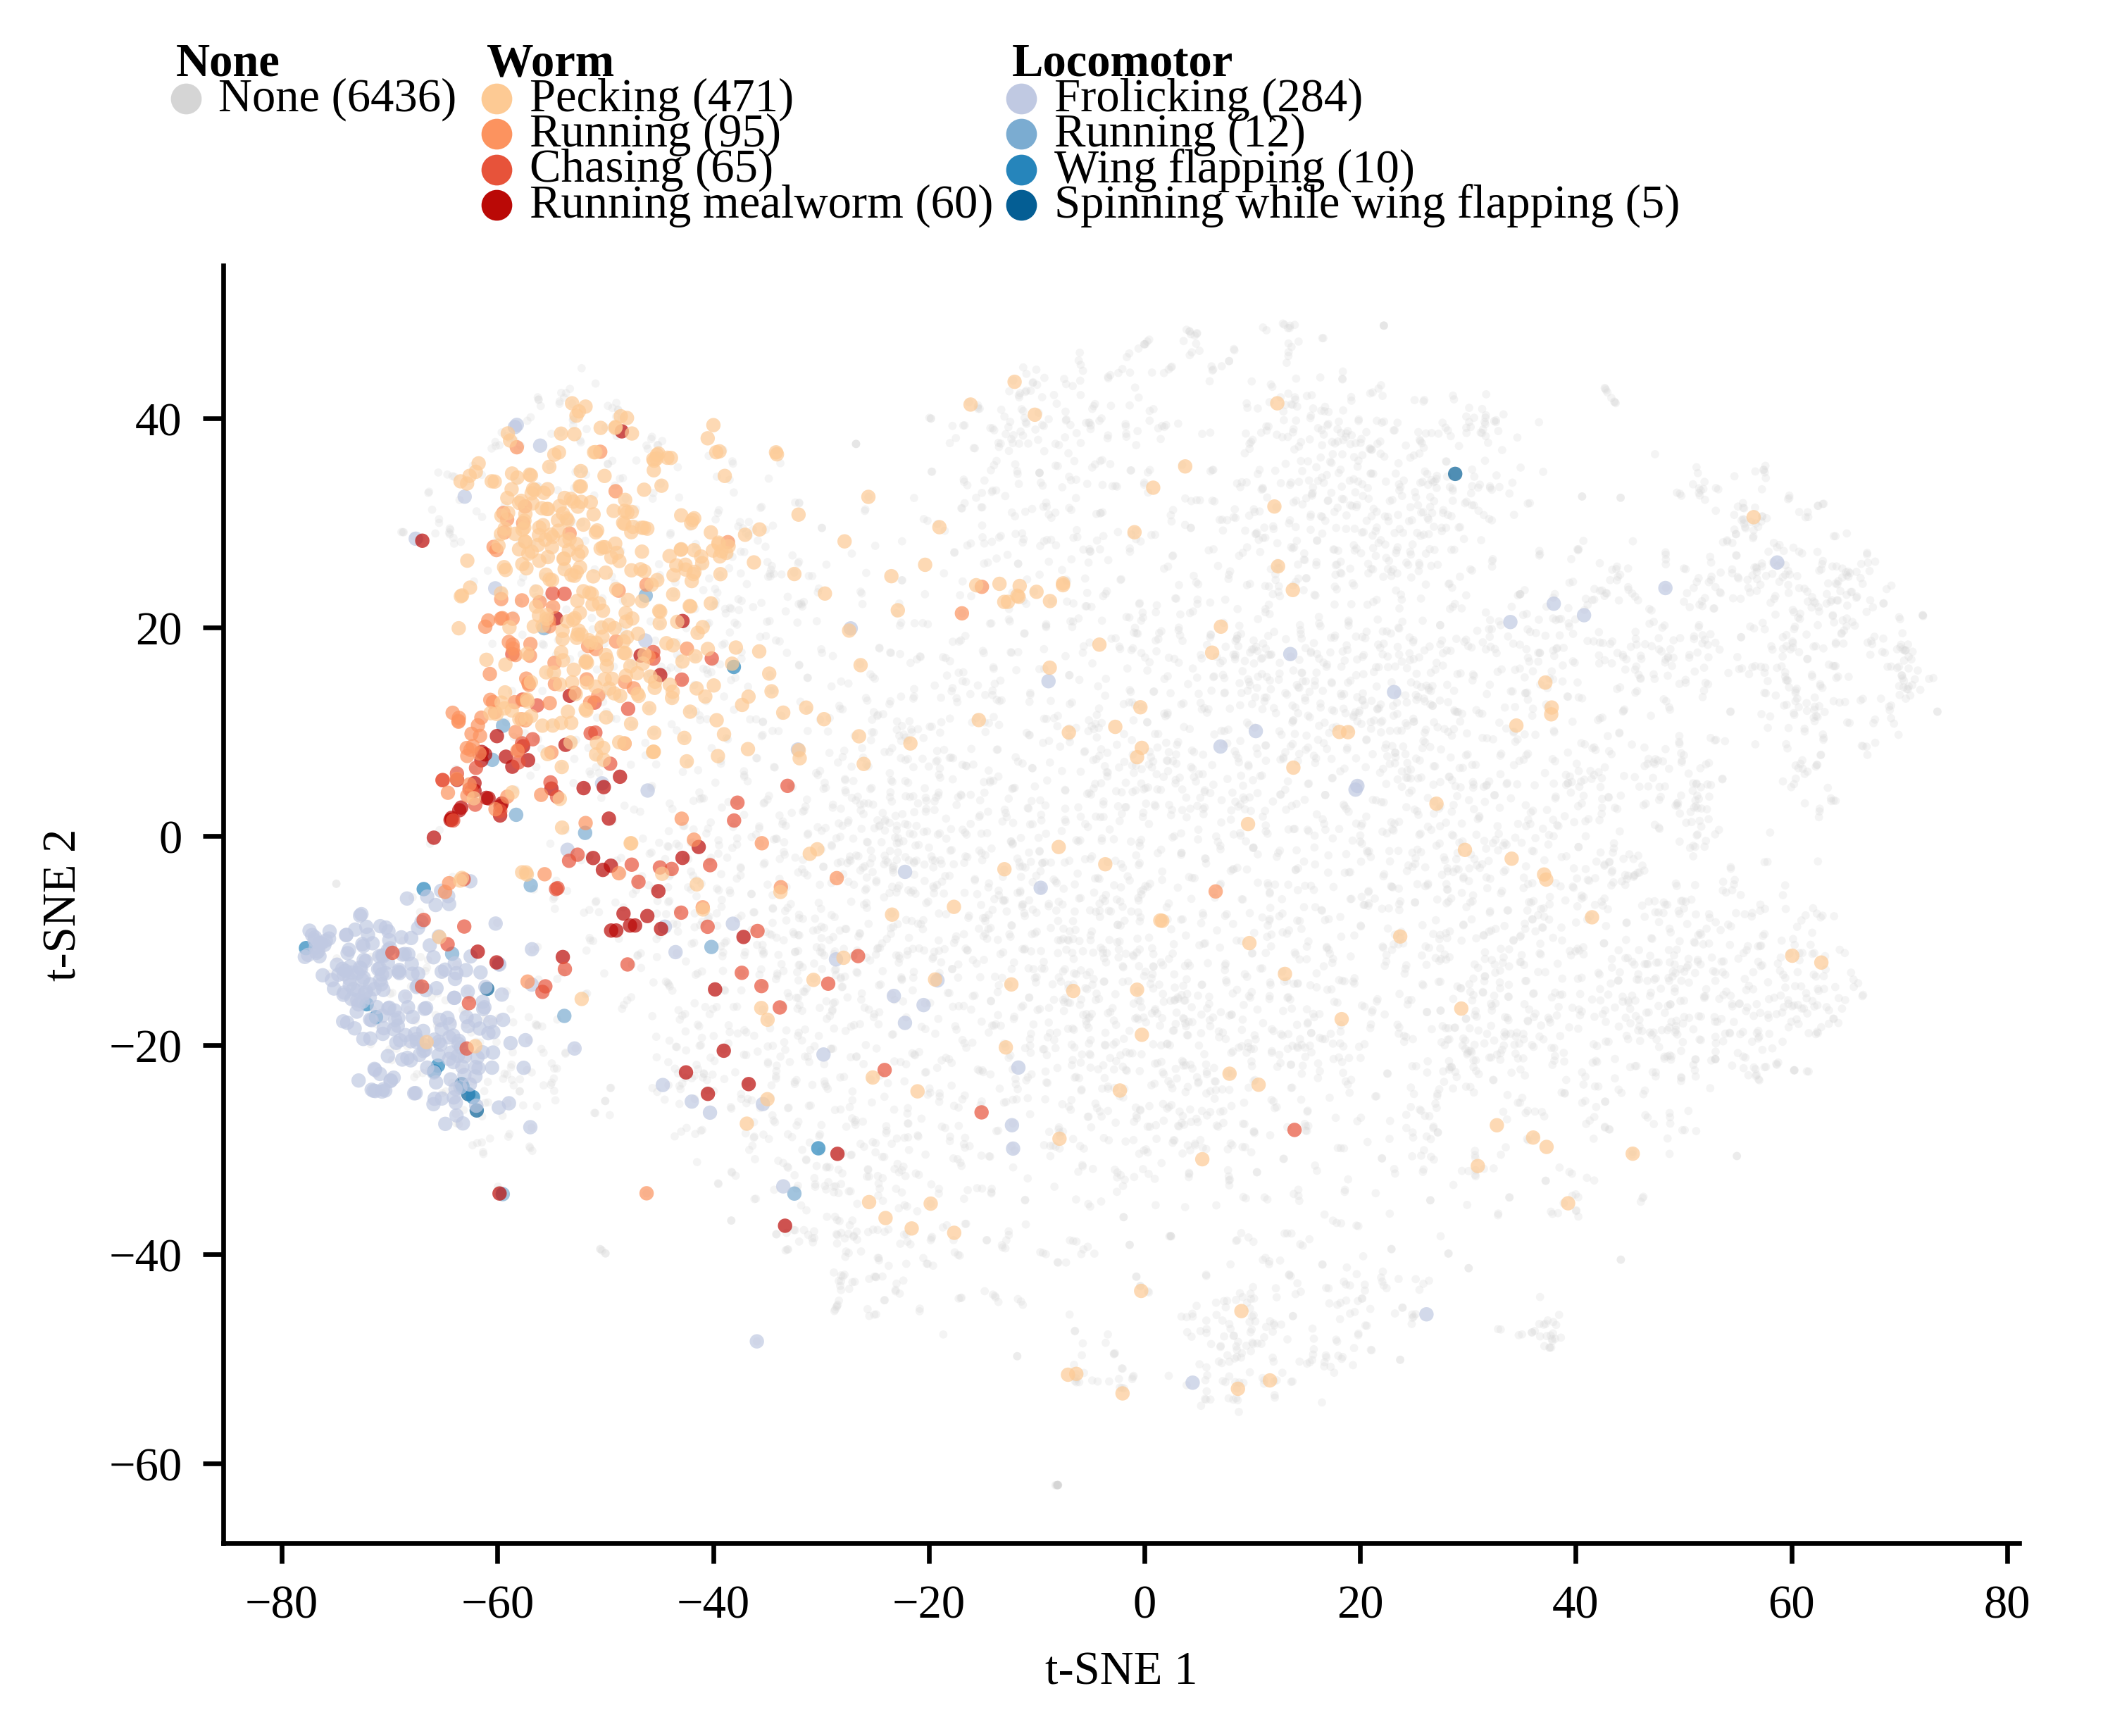

In [34]:
with plt.style.context(".matplotlib/ieee.mplstyle"):
    fig = plt.figure(figsize=(5, 4.2))
    leg_ax = fig.add_axes([0.05, 0.82, 0.92, 0.12])
    ax = fig.add_axes([0.10, 0.10, 0.85, 0.72])

    # Background: none
    ax.scatter(
        X_tsne_single[none_mask_single.values, 0], X_tsne_single[none_mask_single.values, 1],
        c=color_map["None"], s=2, alpha=0.25, edgecolors="none",
    )

    # Active behaviours on top
    for group in ["locomotor", "worm"]:
        gmask = single_df["behav_label"] == group
        behavs = single_df.loc[gmask, "behav_primary"].value_counts().index.tolist()
        for behav in reversed(behavs):
            bmask = single_df["behav_primary"] == behav
            c = color_map.get(behav, "#888888")
            ax.scatter(
                X_tsne_single[bmask.values, 0], X_tsne_single[bmask.values, 1],
                c=[c], s=6, alpha=0.7, edgecolors="none",
            )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    # Custom legend (3-class, no social)
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")

    short_labels = {
        "Worm pecking": "Pecking",
        "Worm running": "Running",
        "Worm chasing": "Chasing",
        "Worm running mealworm": "Running mealworm",
        "Wing flapping": "Wing flapping",
    }

    col_entries_single = {}
    for group in ["none", "worm", "locomotor"]:
        entries = []
        if group == "none":
            n = none_mask_single.sum()
            entries.append((color_map["None"], f"None ({n})"))
        else:
            behavs = single_df.loc[single_df["behav_label"] == group, "behav_primary"].value_counts()
            for behav, count in behavs.items():
                label = short_labels.get(behav, behav)
                entries.append((color_map.get(behav, "#888888"), f"{label} ({count})"))
        col_entries_single[group] = entries

    max_rows_s = max(len(e) for e in col_entries_single.values())
    row_height_s = 1.0 / (max_rows_s + 2)
    col_x_s = [0.03, 0.19, 0.46]

    for col_idx, group in enumerate(["none", "worm", "locomotor"]):
        x = col_x_s[col_idx]
        y = 0.95
        leg_ax.text(x, y, group_labels[group], fontweight="bold",
                    va="center", transform=leg_ax.transAxes)
        for row_idx, (color, label) in enumerate(col_entries_single[group]):
            y = 0.95 - (row_idx + 1) * row_height_s
            leg_ax.scatter(x + 0.005, y, c=[color], s=18, transform=leg_ax.transAxes,
                           clip_on=False, zorder=5)
            leg_ax.text(x + 0.022, y, label, va="center",
                        linespacing=0.8, transform=leg_ax.transAxes)

    sns.despine()
    plt.savefig("img/tsne_dinov3_multiscale.pdf")
    plt.show()